# Phase 3 – Flight Delay Project (EDA + Preprocessing)
---
## Project Overview
## Data Sources (with links)
> **Reproducibility Statement:** All raw files are stored under `data/raw/` and the notebook runs end-to-end without manual downloads.

## Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global Configuration
TARGET_COUNTRIES = ["France", "Germany", "Spain", "Italy", "Netherlands"]

# Load the raw data
eurocontrol_raw = pd.read_csv('../data/raw/eurocontrol_punctuality.csv')
ourairports_raw = pd.read_csv('../data/raw/ourairports_airports.csv')

print(f"EUROCONTROL Raw Shape: {eurocontrol_raw.shape}")
print(f"OurAirports Raw Shape: {ourairports_raw.shape}")

EUROCONTROL Raw Shape: (51419, 8)
OurAirports Raw Shape: (85484, 19)


In [4]:
print("--- EUROCONTROL HEAD ---")
display(eurocontrol_raw.head())
print("\n--- OURAIRPORTS HEAD ---")
display(ourairports_raw.head())

print("\nEUROCONTROL columns:", eurocontrol_raw.columns.tolist())
print("OurAirports columns:", ourairports_raw.columns.tolist())

--- EUROCONTROL HEAD ---


,Date,Airport,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %
0,2022-01-01,Brussels,81.63%,77.63%,12.700680,12.238487,0.462193,89.70%
1,2022-01-02,Brussels,70.19%,69.90%,15.014423,16.865391,-1.850968,91.81%
2,2022-01-03,Brussels,72.12%,75.47%,12.394231,11.233884,1.160347,94.14%
3,2022-01-04,Brussels,80.75%,80.95%,15.807487,14.900088,0.907398,89.30%
4,2022-01-05,Brussels,87.82%,82.59%,9.416244,8.678358,0.737885,97.07%



--- OURAIRPORTS HEAD ---


,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN



EUROCONTROL columns: ['Date', 'Airport', 'Departure Punctuality %', 'Arrival Punctuality %', 'Avg Departure Schedule Delay', 'Avg Arrival Schedule Delay', 'Avg Departure - Arrival Schedule Delay', 'Operated Schedules %']
OurAirports columns: ['id', 'ident', 'type', 'name', 'latitude_deg', 'longitude_deg', 'elevation_ft', 'continent', 'iso_country', 'iso_region', 'municipality', 'scheduled_service', 'icao_code', 'iata_code', 'gps_code', 'local_code', 'home_link', 'wikipedia_link', 'keywords']


In [5]:
import re
import pandas as pd
import numpy as np

TARGET_ISO = ["BE", "DE", "FR", "ES", "IT"]

def norm(s):
    if pd.isna(s):
        return None
    s = str(s).upper().strip()
    s = re.sub(r"[^A-Z0-9 ]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s

euro = eurocontrol_raw.copy()
air = ourairports_raw.copy()

euro["airport_norm"] = euro["Airport"].apply(norm)
air["name_norm"] = air["name"].apply(norm)
air["municipality_norm"] = air["municipality"].apply(norm)

unique_euro = pd.DataFrame({"airport_norm": euro["airport_norm"].dropna().unique()})

# 1) municipality exact match
m1 = unique_euro.merge(
    air[["id","name","municipality","iso_country","iata_code","ident",
         "latitude_deg","longitude_deg","elevation_ft","type","scheduled_service","municipality_norm"]],
    left_on="airport_norm",
    right_on="municipality_norm",
    how="left"
)

# 2) fallback: name contains (less strict)
unmatched = m1[m1["id"].isna()][["airport_norm"]].drop_duplicates()

air_small = air[["id","name","municipality","iso_country","iata_code","ident",
                 "latitude_deg","longitude_deg","elevation_ft","type","scheduled_service","name_norm"]].dropna(subset=["name_norm"]).copy()

matches = []
for a in unmatched["airport_norm"].dropna().unique():
    tmp = air_small[air_small["name_norm"].str.contains(a, na=False)].copy()
    tmp["airport_norm"] = a
    matches.append(tmp)

m2 = pd.concat(matches, ignore_index=True) if matches else pd.DataFrame()

cand = pd.concat([m1[m1["id"].notna()], m2], ignore_index=True)

# Score: prefer target countries, scheduled service, and large airports
type_rank = {"large_airport": 3, "medium_airport": 2, "small_airport": 1}
cand["type_score"] = cand["type"].map(type_rank).fillna(0)
cand["sched_score"] = (cand["scheduled_service"].astype(str).str.lower() == "yes").astype(int)
cand["iata_score"] = cand["iata_code"].notna().astype(int)
cand["target_country_score"] = cand["iso_country"].isin(TARGET_ISO).astype(int)

cand["score"] = cand["type_score"]*10 + cand["sched_score"]*3 + cand["iata_score"]*2 + cand["target_country_score"]*50

best = (
    cand.sort_values(["airport_norm", "score"], ascending=[True, False])
        .drop_duplicates("airport_norm")
        [["airport_norm","id","name","municipality","iso_country","iata_code","ident",
          "latitude_deg","longitude_deg","elevation_ft","type","scheduled_service","score"]]
)

df = euro.merge(best, on="airport_norm", how="left")

print("Best matches rows:", best.shape[0])
print("Overall match rate:", df["id"].notna().mean())

df5 = df[df["iso_country"].isin(TARGET_ISO)].copy()
print("Rows in 5-country dataset:", df5.shape)
print("Countries present:", sorted(df5["iso_country"].dropna().unique()))


Best matches rows: 29
Overall match rate: 0.9062408837200256
Rows in 5-country dataset: (16069, 21)
Countries present: ['BE', 'DE', 'ES', 'FR', 'IT']


In [6]:
# --- Step 2: Prepare merge keys ---

# 1) EUROCONTROL: normalize airport code
euro = eurocontrol_raw.copy()
euro["Airport"] = euro["Airport"].astype(str).str.strip().str.upper()

# 2) OurAirports: use IATA for merge, keep only rows with IATA code
air = ourairports_raw.copy()
air["iata_code"] = air["iata_code"].astype(str).str.strip().str.upper()
air_iata = air[air["iata_code"].notna() & (air["iata_code"] != "NAN")].copy()

# 3) Merge (left join keeps all EUROCONTROL rows)
merged = euro.merge(
    air_iata,
    left_on="Airport",
    right_on="iata_code",
    how="left",
    suffixes=("", "_air")
)

print("Merged shape:", merged.shape)
print("Merge match rate:", merged["iata_code"].notna().mean())
merged.head()

Merged shape: (51419, 27)
Merge match rate: 0.0


,Date,Airport,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %,id,ident,...,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,2022-01-01,BRUSSELS,81.63%,77.63%,12.700680,12.238487,0.462193,89.70%,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-02,BRUSSELS,70.19%,69.90%,15.014423,16.865391,-1.850968,91.81%,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-03,BRUSSELS,72.12%,75.47%,12.394231,11.233884,1.160347,94.14%,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-04,BRUSSELS,80.75%,80.95%,15.807487,14.900088,0.907398,89.30%,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-05,BRUSSELS,87.82%,82.59%,9.416244,8.678358,0.737885,97.07%,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Inspect the airport field
print("Unique EUROCONTROL airports:", eurocontrol_raw["Airport"].nunique())
display(eurocontrol_raw["Airport"].value_counts().head(20))
display(pd.Series(sorted(eurocontrol_raw["Airport"].dropna().astype(str).str.upper().unique())[:50]))

Unique EUROCONTROL airports: 32


Airport
Brussels                   1607
Frankfurt                  1607
Istanbul Sabiha Gokcen     1607
Antalya                    1607
Zurich                     1607
Geneva                     1607
Lisbon                     1607
Vienna                     1607
Tel Aviv                   1607
Rome Fiumicino             1607
Milan Malpensa             1607
Athens                     1607
Paris Orly                 1607
Paris Charles de Gaulle    1607
Nice                       1607
Palma de Mallorca          1607
Madrid Barajas             1607
Barcelona                  1607
Stockholm Arlanda          1607
Warsaw Chopin              1607
Name: count, dtype: int64

0                   AMSTERDAM
1                     ANTALYA
2                      ATHENS
3                   BARCELONA
4                    BRUSSELS
5                  COPENHAGEN
6                      DUBLIN
7                  DUSSELDORF
8                   FRANKFURT
9                      GENEVA
10                   HELSINKI
11                   ISTANBUL
12     ISTANBUL SABIHA GOKCEN
13                     LISBON
14             LONDON GATWICK
15            LONDON HEATHROW
16            LONDON STANSTED
17             MADRID BARAJAS
18                 MANCHESTER
19             MILAN MALPENSA
20                     MUNICH
21                       NICE
22                       OSLO
23          PALMA DE MALLORCA
24    PARIS CHARLES DE GAULLE
25                 PARIS ORLY
26             ROME FIUMICINO
27          STOCKHOLM ARLANDA
28                   TEL AVIV
29                     VIENNA
30              WARSAW CHOPIN
31                     ZURICH
dtype: object

In [8]:
import re

def norm(s):
    if pd.isna(s):
        return None
    s = str(s).upper().strip()
    s = re.sub(r"[^A-Z0-9 ]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s

euro = eurocontrol_raw.copy()
air = ourairports_raw.copy()

euro["airport_norm"] = euro["Airport"].apply(norm)
air["name_norm"] = air["name"].apply(norm)
air["municipality_norm"] = air["municipality"].apply(norm)

# Build a candidate mapping by matching EUROCONTROL Airport to either municipality or airport name
unique_euro = pd.DataFrame({"airport_norm": euro["airport_norm"].dropna().unique()})

# Match 1: municipality match (often works when EUROCONTROL uses city name)
m1 = unique_euro.merge(
    air[["id", "name", "municipality", "iso_country", "iata_code", "ident", "latitude_deg", "longitude_deg", "elevation_ft", "type", "scheduled_service", "municipality_norm"]],
    left_on="airport_norm",
    right_on="municipality_norm",
    how="left"
)

# Match 2: airport name contains the term (fallback)
# (We’ll do this only for the unmatched ones to reduce noise)
unmatched = m1[m1["id"].isna()][["airport_norm"]].drop_duplicates()

air_small = air[["id", "name", "municipality", "iso_country", "iata_code", "ident", "latitude_deg", "longitude_deg", "elevation_ft", "type", "scheduled_service", "name_norm"]].dropna(subset=["name_norm"]).copy()

# simple contains-match: airport_norm appears in name_norm
matches = []
for a in unmatched["airport_norm"].dropna().unique():
    tmp = air_small[air_small["name_norm"].str.contains(rf"\b{re.escape(a)}\b", regex=True, na=False)].copy()
    tmp["airport_norm"] = a
    matches.append(tmp)

m2 = pd.concat(matches, ignore_index=True) if matches else pd.DataFrame()

print("Municipality matches:", m1["id"].notna().sum(), "out of", len(unique_euro))
print("Fallback name matches rows:", len(m2))

display(m1[m1["id"].notna()].head(10))
display(m2.head(10))

Municipality matches: 189 out of 32
Fallback name matches rows: 9


,airport_norm,id,name,municipality,iso_country,iata_code,ident,latitude_deg,longitude_deg,elevation_ft,type,scheduled_service,municipality_norm
0,BRUSSELS,11463.0,Brussels Heliport,Brussels,US,NaN,4IL7,38.945801,-90.587196,515.0,heliport,no,BRUSSELS
1,BRUSSELS,14466.0,Crispy Cedars Airport,Brussels,US,NaN,7WI8,44.780722,-87.602737,700.0,small_airport,no,BRUSSELS
2,BRUSSELS,429993.0,Queen Astrid Military Hospital Heliport,Brussels,BE,NaN,BE-0019,50.905270,4.389360,209.0,heliport,no,BRUSSELS
3,BRUSSELS,43719.0,ULB Heliport,Brussels,BE,NaN,BE-0055,50.811847,4.260989,108.0,closed,no,BRUSSELS
4,BRUSSELS,594415.0,Brussels Heliport,Brussels,BE,NaN,BE-0077,50.860630,4.351370,62.0,closed,no,BRUSSELS
5,BRUSSELS,594416.0,Brussels Expo58 Heliport,Brussels,BE,NaN,BE-0078,50.899320,4.331960,220.0,closed,no,BRUSSELS
6,BRUSSELS,298546.0,Brussels / Hemingway Field,Brussels,CA,NaN,CA-0482,43.718487,-81.238171,1148.0,small_airport,no,BRUSSELS
7,BRUSSELS,321396.0,Brussels/Van Keulen Field,Brussels,CA,NaN,CA-0678,43.783300,-81.195802,1118.0,closed,no,BRUSSELS
8,BRUSSELS,1390.0,Brussels (Armstrong Field) Airport,Brussels,CA,NaN,CPD4,43.749079,-81.237341,1100.0,small_airport,no,BRUSSELS
9,FRANKFURT,599479.0,Frankfurt am Main Accident Hospital Roof Helipad,Frankfurt,DE,NaN,DE-0922,50.145472,8.708981,NaN,heliport,no,FRANKFURT


,id,name,municipality,iso_country,iata_code,ident,latitude_deg,longitude_deg,elevation_ft,type,scheduled_service,name_norm,airport_norm
0,2429,London Gatwick Airport,London,GB,LGW,EGKK,51.148744,-0.185739,202.0,large_airport,yes,LONDON GATWICK AIRPORT,LONDON GATWICK
1,2434,London Heathrow Airport,London,GB,LHR,EGLL,51.470748,-0.459909,83.0,large_airport,yes,LONDON HEATHROW AIRPORT,LONDON HEATHROW
2,2476,London Stansted Airport,"London, Essex",GB,STN,EGSS,51.884998,0.235000,348.0,large_airport,yes,LONDON STANSTED AIRPORT,LONDON STANSTED
3,2637,Warsaw Chopin Airport,Warsaw,PL,WAW,EPWA,52.165699,20.967100,362.0,large_airport,yes,WARSAW CHOPIN AIRPORT,WARSAW CHOPIN
4,2701,Stockholm-Arlanda Airport,Stockholm,SE,ARN,ESSA,59.648490,17.928829,137.0,large_airport,yes,STOCKHOLM ARLANDA AIRPORT,STOCKHOLM ARLANDA
5,4019,Adolfo Suárez Madrid–Barajas Airport,Madrid,ES,MAD,LEMD,40.493407,-3.572249,1998.0,large_airport,yes,ADOLFO SU REZ MADRID BARAJAS AIRPORT,MADRID BARAJAS
6,4189,Paris-Orly Airport,"Paris (Orly, Val-de-Marne)",FR,ORY,LFPO,48.729499,2.358963,291.0,large_airport,yes,PARIS ORLY AIRPORT,PARIS ORLY
7,4340,Milan Malpensa International Airport,Ferno (VA),IT,MXP,LIMC,45.630600,8.728110,768.0,large_airport,yes,MILAN MALPENSA INTERNATIONAL AIRPORT,MILAN MALPENSA
8,4372,Rome–Fiumicino Leonardo da Vinci International...,Rome,IT,FCO,LIRF,41.804532,12.251998,13.0,large_airport,yes,ROME FIUMICINO LEONARDO DA VINCI INTERNATIONAL...,ROME FIUMICINO


In [9]:
# Combine candidates
cand = pd.concat([
    m1[m1["id"].notna()],
    m2
], ignore_index=True)

# Quality scoring to choose best match per airport_norm
type_rank = {"large_airport": 3, "medium_airport": 2, "small_airport": 1}
cand["type_score"] = cand["type"].map(type_rank).fillna(0)
cand["sched_score"] = (cand["scheduled_service"].astype(str).str.lower() == "yes").astype(int)
cand["iata_score"] = cand["iata_code"].notna().astype(int)

cand["score"] = cand["type_score"]*10 + cand["sched_score"]*3 + cand["iata_score"]*2

best = (
    cand.sort_values(["airport_norm", "score"], ascending=[True, False])
        .drop_duplicates("airport_norm")
        [["airport_norm","id","name","municipality","iso_country","iata_code","ident","latitude_deg","longitude_deg","elevation_ft","type","scheduled_service","score"]]
)

print("Best matches:", best.shape)
display(best.head(20))

# Merge best matches back into euro rows
df = euro.merge(best, on="airport_norm", how="left", suffixes=("", "_air"))

print("Final match rate:", df["id"].notna().mean())
df.head()

Best matches: (29, 13)


,airport_norm,id,name,municipality,iso_country,iata_code,ident,latitude_deg,longitude_deg,elevation_ft,type,scheduled_service,score
41,AMSTERDAM,2513.0,Amsterdam Airport Schiphol,Amsterdam,NL,AMS,EHAM,52.308601,4.763890,-11.0,large_airport,yes,35.0
178,ANTALYA,4515.0,Antalya International Airport,Antalya,TR,AYT,LTAI,36.898701,30.800501,177.0,large_airport,yes,35.0
121,ATHENS,3369.0,Athens Ben Epps Airport,Athens,US,AHN,KAHN,33.948842,-83.325634,808.0,medium_airport,no,22.0
89,BARCELONA,4004.0,Josep Tarradellas Barcelona-El Prat Airport,Barcelona,ES,BCN,LEBL,41.297100,2.078460,12.0,large_airport,yes,35.0
1,BRUSSELS,14466.0,Crispy Cedars Airport,Brussels,US,NaN,7WI8,44.780722,-87.602737,700.0,small_airport,no,10.0
79,COPENHAGEN,2542.0,Copenhagen Kastrup Airport,Copenhagen,DK,CPH,EKCH,55.617901,12.656000,17.0,large_airport,yes,35.0
58,DUBLIN,2533.0,Dublin Airport,Dublin,IE,DUB,EIDW,53.428713,-6.262121,242.0,large_airport,yes,35.0
9,FRANKFURT,599479.0,Frankfurt am Main Accident Hospital Roof Helipad,Frankfurt,DE,NaN,DE-0922,50.145472,8.708981,NaN,heliport,no,0.0
168,GENEVA,4490.0,Geneva International Airport,Geneva,CH,GVA,LSGG,46.238098,6.108950,1411.0,large_airport,yes,35.0
13,HELSINKI,43021.0,Hernesaari Heliport,Helsinki,FI,HEN,EFHE,60.147778,24.924444,7.0,heliport,no,2.0


Final match rate: 0.9062408837200256


,Date,Airport,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %,airport_norm,id,...,municipality,iso_country,iata_code,ident,latitude_deg,longitude_deg,elevation_ft,type,scheduled_service,score
0,2022-01-01,Brussels,81.63%,77.63%,12.700680,12.238487,0.462193,89.70%,BRUSSELS,14466.0,...,Brussels,US,NaN,7WI8,44.780722,-87.602737,700.0,small_airport,no,10.0
1,2022-01-02,Brussels,70.19%,69.90%,15.014423,16.865391,-1.850968,91.81%,BRUSSELS,14466.0,...,Brussels,US,NaN,7WI8,44.780722,-87.602737,700.0,small_airport,no,10.0
2,2022-01-03,Brussels,72.12%,75.47%,12.394231,11.233884,1.160347,94.14%,BRUSSELS,14466.0,...,Brussels,US,NaN,7WI8,44.780722,-87.602737,700.0,small_airport,no,10.0
3,2022-01-04,Brussels,80.75%,80.95%,15.807487,14.900088,0.907398,89.30%,BRUSSELS,14466.0,...,Brussels,US,NaN,7WI8,44.780722,-87.602737,700.0,small_airport,no,10.0
4,2022-01-05,Brussels,87.82%,82.59%,9.416244,8.678358,0.737885,97.07%,BRUSSELS,14466.0,...,Brussels,US,NaN,7WI8,44.780722,-87.602737,700.0,small_airport,no,10.0


In [10]:
TARGET_ISO = ["BE", "DE", "FR", "ES", "IT"]

import re
import pandas as pd

def norm(s):
    if pd.isna(s):
        return None
    s = str(s).upper().strip()
    s = re.sub(r"[^A-Z0-9 ]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s

euro = eurocontrol_raw.copy()
air = ourairports_raw.copy()

euro["airport_norm"] = euro["Airport"].apply(norm)
air["name_norm"] = air["name"].apply(norm)
air["municipality_norm"] = air["municipality"].apply(norm)

air = air[air["iso_country"].isin(TARGET_ISO)].copy()

unique_euro = pd.DataFrame({"airport_norm": euro["airport_norm"].dropna().unique()})

m1 = unique_euro.merge(
    air[["id", "name", "municipality", "iso_country", "iata_code", "ident",
         "latitude_deg", "longitude_deg", "elevation_ft", "type", "scheduled_service", "municipality_norm"]],
    left_on="airport_norm",
    right_on="municipality_norm",
    how="left"
)

unmatched = m1[m1["id"].isna()][["airport_norm"]].drop_duplicates()
air_small = air[["id", "name", "municipality", "iso_country", "iata_code", "ident",
                 "latitude_deg", "longitude_deg", "elevation_ft", "type", "scheduled_service", "name_norm"]].dropna(subset=["name_norm"]).copy()

matches = []
for a in unmatched["airport_norm"].dropna().unique():
    tmp = air_small[air_small["name_norm"].str.contains(rf"\b{re.escape(a)}\b", regex=True, na=False)].copy()
    tmp["airport_norm"] = a
    matches.append(tmp)

m2 = pd.concat(matches, ignore_index=True) if matches else pd.DataFrame()
cand = pd.concat([m1[m1["id"].notna()], m2], ignore_index=True)

type_rank = {"large_airport": 3, "medium_airport": 2, "small_airport": 1}
cand["type_score"] = cand["type"].map(type_rank).fillna(0)
cand["sched_score"] = (cand["scheduled_service"].astype(str).str.lower() == "yes").astype(int)
cand["iata_score"] = cand["iata_code"].notna().astype(int)
cand["score"] = cand["type_score"]*10 + cand["sched_score"]*3 + cand["iata_score"]*2

best = (
    cand.sort_values(["airport_norm", "score"], ascending=[True, False])
        .drop_duplicates("airport_norm")
        [["airport_norm","id","name","municipality","iso_country","iata_code","ident",
          "latitude_deg","longitude_deg","elevation_ft","type","scheduled_service","score"]]
)

df = euro.merge(best, on="airport_norm", how="left")

print("Best matches rows:", best.shape[0])
print("Final match rate:", df["id"].notna().mean())

Best matches rows: 11
Final match rate: 0.3437639782959606


In [11]:
df_work = df5.copy()

# Standardize text columns (safe)
for c in ["Airport", "municipality", "iso_country", "type", "scheduled_service"]:
    if c in df_work.columns:
        df_work[c] = df_work[c].astype(str).str.strip()

print("Starting df_work shape:", df_work.shape)
df_work.head()

Starting df_work shape: (16069, 21)


,Date,Airport,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %,airport_norm,id,...,municipality,iso_country,iata_code,ident,latitude_deg,longitude_deg,elevation_ft,type,scheduled_service,score
0,2022-01-01,Brussels,81.63%,77.63%,12.700680,12.238487,0.462193,89.70%,BRUSSELS,429993.0,...,Brussels,BE,NaN,BE-0019,50.90527,4.38936,209.0,heliport,no,50.0
1,2022-01-02,Brussels,70.19%,69.90%,15.014423,16.865391,-1.850968,91.81%,BRUSSELS,429993.0,...,Brussels,BE,NaN,BE-0019,50.90527,4.38936,209.0,heliport,no,50.0
2,2022-01-03,Brussels,72.12%,75.47%,12.394231,11.233884,1.160347,94.14%,BRUSSELS,429993.0,...,Brussels,BE,NaN,BE-0019,50.90527,4.38936,209.0,heliport,no,50.0
3,2022-01-04,Brussels,80.75%,80.95%,15.807487,14.900088,0.907398,89.30%,BRUSSELS,429993.0,...,Brussels,BE,NaN,BE-0019,50.90527,4.38936,209.0,heliport,no,50.0
4,2022-01-05,Brussels,87.82%,82.59%,9.416244,8.678358,0.737885,97.07%,BRUSSELS,429993.0,...,Brussels,BE,NaN,BE-0019,50.90527,4.38936,209.0,heliport,no,50.0


In [12]:
import numpy as np
import pandas as pd

# Find columns that look like % values
pct_candidates = [c for c in df_work.columns if "Punctuality" in c or c.endswith("%")]

print("Percentage-like columns:", pct_candidates)

for c in pct_candidates:
    df_work[c] = (
        df_work[c]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )
    df_work[c] = pd.to_numeric(df_work[c], errors="coerce")

df_work[pct_candidates].head()

Percentage-like columns: ['Departure Punctuality %', 'Arrival Punctuality %', 'Operated Schedules %']


,Departure Punctuality %,Arrival Punctuality %,Operated Schedules %
0,81.63,77.63,89.70
1,70.19,69.90,91.81
2,72.12,75.47,94.14
3,80.75,80.95,89.30
4,87.82,82.59,97.07


In [13]:
delay_candidates = [c for c in df_work.columns if "Delay" in c or "Schedule" in c]
print("Delay-like columns:", delay_candidates)

for c in delay_candidates:
    df_work[c] = pd.to_numeric(df_work[c], errors="coerce")

df_work[delay_candidates].head()

Delay-like columns: ['Avg Departure Schedule Delay', 'Avg Arrival Schedule Delay', 'Avg Departure - Arrival Schedule Delay', 'Operated Schedules %']


,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %
0,12.700680,12.238487,0.462193,89.70
1,15.014423,16.865391,-1.850968,91.81
2,12.394231,11.233884,1.160347,94.14
3,15.807487,14.900088,0.907398,89.30
4,9.416244,8.678358,0.737885,97.07


In [14]:
# Parse date
df_work["date"] = pd.to_datetime(df_work["Date"], errors="coerce")

# Remove duplicates by airport-day (important for “airport-day” unit of analysis)
before = df_work.shape[0]
df_work = df_work.drop_duplicates(subset=["date", "Airport"]).copy()
after = df_work.shape[0]

print("Rows before dedupe:", before)
print("Rows after dedupe:", after)
print("Unparsed dates (NaT rate):", df_work["date"].isna().mean())
df_work[["Date", "date", "Airport", "iso_country"]].head()

Rows before dedupe: 16069
Rows after dedupe: 16069
Unparsed dates (NaT rate): 0.0


,Date,date,Airport,iso_country
0,2022-01-01,2022-01-01,Brussels,BE
1,2022-01-02,2022-01-02,Brussels,BE
2,2022-01-03,2022-01-03,Brussels,BE
3,2022-01-04,2022-01-04,Brussels,BE
4,2022-01-05,2022-01-05,Brussels,BE


In [15]:
missing = (df_work.isna().mean() * 100).sort_values(ascending=False)
missing_report = missing[missing > 0].round(2)

print("Columns with missing values (%):")
display(missing_report)

print("Final cleaned df_work shape:", df_work.shape)

Columns with missing values (%):


iata_code       30.0
elevation_ft    10.0
dtype: float64

Final cleaned df_work shape: (16069, 22)


In [16]:
print("df_work shape:", df_work.shape)
print("Countries:", sorted(df_work["iso_country"].dropna().unique()))
print("NaT rate:", df_work["date"].isna().mean())
print("Top 5 missing columns:", (df_work.isna().mean().sort_values(ascending=False).head(5)))

df_work shape: (16069, 22)
Countries: ['BE', 'DE', 'ES', 'FR', 'IT']
NaT rate: 0.0
Top 5 missing columns: iata_code       0.300019
elevation_ft    0.100006
Date            0.000000
Airport         0.000000
score           0.000000
dtype: float64


In [17]:
df_clean = df_work.copy()

# 1) Handle missing values (simple + acceptable for Phase 3)
# Keep iata_code even if missing (it's not essential for analysis)
# Fill elevation_ft with median (better than dropping 10% of rows)
if "elevation_ft" in df_clean.columns:
    df_clean["elevation_ft"] = df_clean["elevation_ft"].fillna(df_clean["elevation_ft"].median())

# 2) Optional: drop rows missing the key delay/punctuality metrics (only if needed)
# (We will decide the exact target column in Step 6)
# For now, just report missingness of the key EUROCONTROL numeric columns:
key_cols = [c for c in df_clean.columns if "Punctuality" in c or "Delay" in c]
missing_key = (df_clean[key_cols].isna().mean() * 100).sort_values(ascending=False).round(2)

print("df_clean shape:", df_clean.shape)
print("Top missing % among key punctuality/delay columns:")
display(missing_key.head(10))

df_clean shape: (16069, 22)
Top missing % among key punctuality/delay columns:


Departure Punctuality %                   0.0
Arrival Punctuality %                     0.0
Avg Departure Schedule Delay              0.0
Avg Arrival Schedule Delay                0.0
Avg Departure - Arrival Schedule Delay    0.0
dtype: float64

In [18]:
df_feat = df_clean.copy()

# ---- Date features (airport-day) ----
df_feat["year"] = df_feat["date"].dt.year
df_feat["month"] = df_feat["date"].dt.month
df_feat["weekday"] = df_feat["date"].dt.weekday
df_feat["is_weekend"] = df_feat["weekday"].isin([5, 6]).astype(int)

def season_from_month(m):
    if m in [12, 1, 2]:
        return "Winter"
    if m in [3, 4, 5]:
        return "Spring"
    if m in [6, 7, 8]:
        return "Summer"
    return "Fall"

df_feat["season"] = df_feat["month"].apply(season_from_month)

# ---- Key numeric metrics ----
df_feat["dep_punctuality_pct"] = df_feat["Departure Punctuality %"]
df_feat["arr_punctuality_pct"] = df_feat["Arrival Punctuality %"]
df_feat["dep_delay_min"] = df_feat["Avg Departure Schedule Delay"]
df_feat["arr_delay_min"] = df_feat["Avg Arrival Schedule Delay"]
df_feat["dep_minus_arr_delay_min"] = df_feat["Avg Departure - Arrival Schedule Delay"]

# ---- Target(s) for Phase 4 ----
# Regression target:
df_feat["target_delay_minutes"] = df_feat["arr_delay_min"]

# Classification target (delayed if arrival delay > 15 min):
df_feat["target_delayed_15"] = (df_feat["arr_delay_min"] > 15).astype(int)

# Optional: category target
df_feat["target_delay_category"] = pd.cut(
    df_feat["arr_delay_min"],
    bins=[-np.inf, 5, 15, 60, np.inf],
    labels=["On-time", "Minor", "Moderate", "Severe"]
)

# ---- Airport metadata features (already in df_clean from OurAirports) ----
# Keep these columns if they exist:
keep_cols = [
    "Airport", "iso_country", "municipality", "type", "scheduled_service",
    "latitude_deg", "longitude_deg", "elevation_ft"
]
for c in keep_cols:
    if c not in df_feat.columns:
        print("Missing expected metadata column:", c)

print("df_feat shape:", df_feat.shape)
df_feat.head()

df_feat shape: (16069, 35)


,Date,Airport,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %,airport_norm,id,...,is_weekend,season,dep_punctuality_pct,arr_punctuality_pct,dep_delay_min,arr_delay_min,dep_minus_arr_delay_min,target_delay_minutes,target_delayed_15,target_delay_category
0,2022-01-01,Brussels,81.63,77.63,12.700680,12.238487,0.462193,89.70,BRUSSELS,429993.0,...,1,Winter,81.63,77.63,12.700680,12.238487,0.462193,12.238487,0,Minor
1,2022-01-02,Brussels,70.19,69.90,15.014423,16.865391,-1.850968,91.81,BRUSSELS,429993.0,...,1,Winter,70.19,69.90,15.014423,16.865391,-1.850968,16.865391,1,Moderate
2,2022-01-03,Brussels,72.12,75.47,12.394231,11.233884,1.160347,94.14,BRUSSELS,429993.0,...,0,Winter,72.12,75.47,12.394231,11.233884,1.160347,11.233884,0,Minor
3,2022-01-04,Brussels,80.75,80.95,15.807487,14.900088,0.907398,89.30,BRUSSELS,429993.0,...,0,Winter,80.75,80.95,15.807487,14.900088,0.907398,14.900088,0,Minor
4,2022-01-05,Brussels,87.82,82.59,9.416244,8.678358,0.737885,97.07,BRUSSELS,429993.0,...,0,Winter,87.82,82.59,9.416244,8.678358,0.737885,8.678358,0,Minor


In [19]:
feature_cols = [
    # date features
    "year","month","weekday","is_weekend","season",
    # airport metadata
    "iso_country","municipality","type","scheduled_service",
    "latitude_deg","longitude_deg","elevation_ft",
    # numeric punctuality/delay
    "dep_punctuality_pct","arr_punctuality_pct",
    "dep_delay_min","arr_delay_min","dep_minus_arr_delay_min"
]

missing_features = [c for c in feature_cols if c not in df_feat.columns]
print("Missing from feature_cols:", missing_features)
print("Count of planned features:", len(feature_cols) - len(missing_features))

print("Targets missing rate:")
print("target_delay_minutes:", df_feat["target_delay_minutes"].isna().mean())
print("target_delayed_15:", df_feat["target_delayed_15"].isna().mean())

df_feat[feature_cols + ["target_delay_minutes","target_delayed_15"]].head()

Missing from feature_cols: []
Count of planned features: 17
Targets missing rate:
target_delay_minutes: 0.0
target_delayed_15: 0.0


,year,month,weekday,is_weekend,season,iso_country,municipality,type,scheduled_service,latitude_deg,longitude_deg,elevation_ft,dep_punctuality_pct,arr_punctuality_pct,dep_delay_min,arr_delay_min,dep_minus_arr_delay_min,target_delay_minutes,target_delayed_15
0,2022,1,5,1,Winter,BE,Brussels,heliport,no,50.90527,4.38936,209.0,81.63,77.63,12.700680,12.238487,0.462193,12.238487,0
1,2022,1,6,1,Winter,BE,Brussels,heliport,no,50.90527,4.38936,209.0,70.19,69.90,15.014423,16.865391,-1.850968,16.865391,1
2,2022,1,0,0,Winter,BE,Brussels,heliport,no,50.90527,4.38936,209.0,72.12,75.47,12.394231,11.233884,1.160347,11.233884,0
3,2022,1,1,0,Winter,BE,Brussels,heliport,no,50.90527,4.38936,209.0,80.75,80.95,15.807487,14.900088,0.907398,14.900088,0
4,2022,1,2,0,Winter,BE,Brussels,heliport,no,50.90527,4.38936,209.0,87.82,82.59,9.416244,8.678358,0.737885,8.678358,0


In [20]:
# Basic dataset summary
print("Rows:", df_feat.shape[0])
print("Columns:", df_feat.shape[1])
print("Countries:", sorted(df_feat["iso_country"].unique()))

# Delay summary by country
delay_by_country = (
    df_feat.groupby("iso_country")["target_delay_minutes"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)
display(delay_by_country)

# Delay summary by month
delay_by_month = (
    df_feat.groupby("month")["target_delay_minutes"]
    .agg(["count", "mean", "median"])
    .sort_values("month")
)
display(delay_by_month)

# Top airports by average delay (show top 15)
top_airports_delay = (
    df_feat.groupby(["iso_country", "Airport"])["target_delay_minutes"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
display(top_airports_delay)

Rows: 16069
Columns: 35
Countries: ['BE', 'DE', 'ES', 'FR', 'IT']


,count,mean,median,std
iso_country,,,,
IT,3214,14.776180,13.285124,7.395083
BE,1607,14.310494,13.374593,5.934773
FR,3214,13.634439,11.799364,8.081394
DE,3213,13.576139,12.016898,7.632270
ES,4821,13.038681,11.227263,8.899973


,count,mean,median
month,,,
1,1550,10.961160,9.523414
2,1410,9.389933,8.293568
3,1550,10.269098,8.721877
4,1500,11.707150,10.763764
5,1500,12.989148,11.663696
6,1200,18.408440,16.527555
7,1240,21.030215,19.222249
8,1240,17.565874,15.690828
9,1200,16.979032,15.205545


iso_country  Airport          
IT           Milan Malpensa       16.578592
DE           Frankfurt            14.910968
FR           Nice                 14.634686
BE           Brussels             14.310494
ES           Barcelona            13.658403
             Palma de Mallorca    13.630297
IT           Rome Fiumicino       12.973768
FR           Paris Orly           12.634192
DE           Munich               12.240479
ES           Madrid Barajas       11.827342
Name: target_delay_minutes, dtype: float64

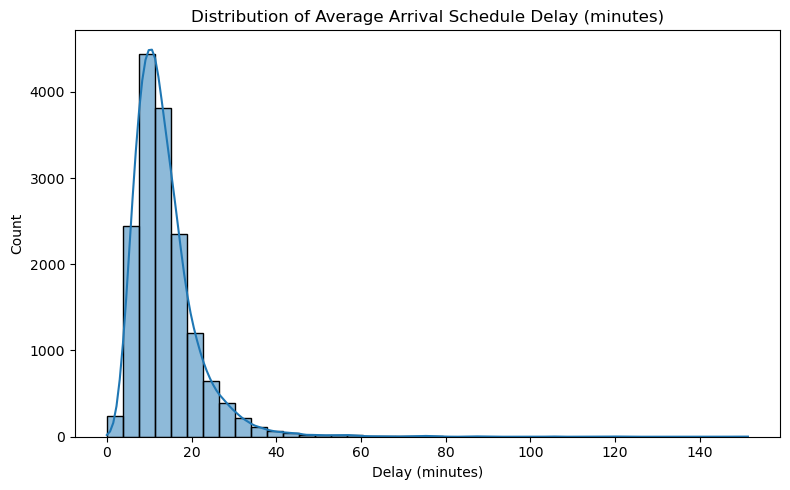

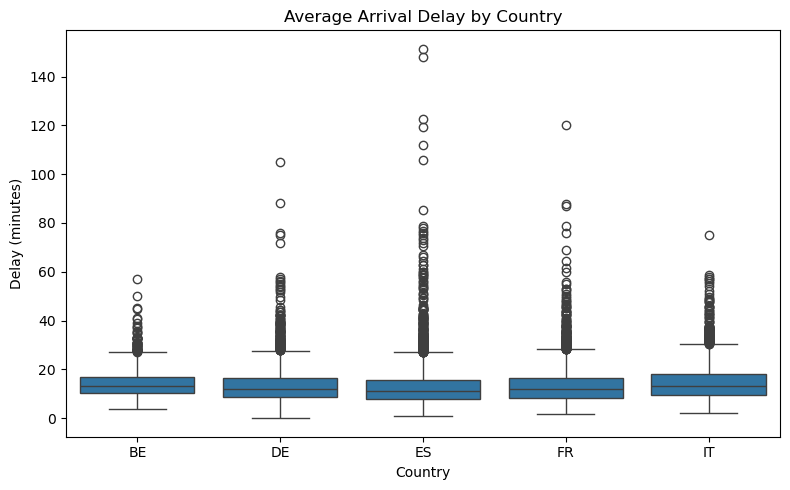

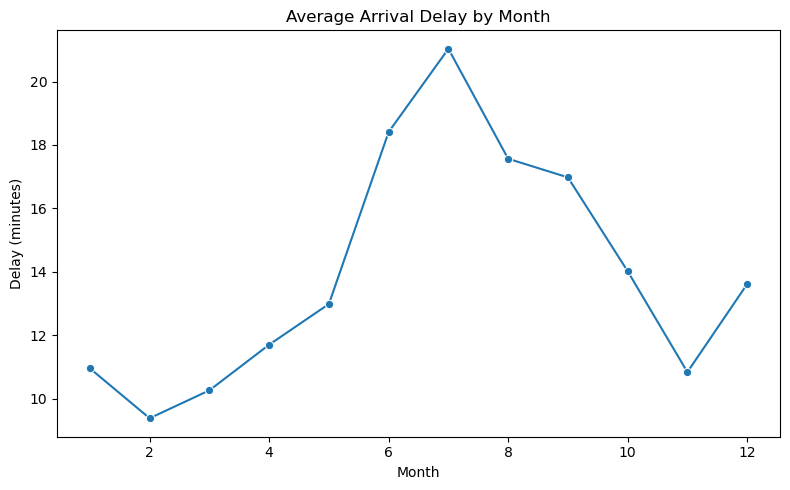

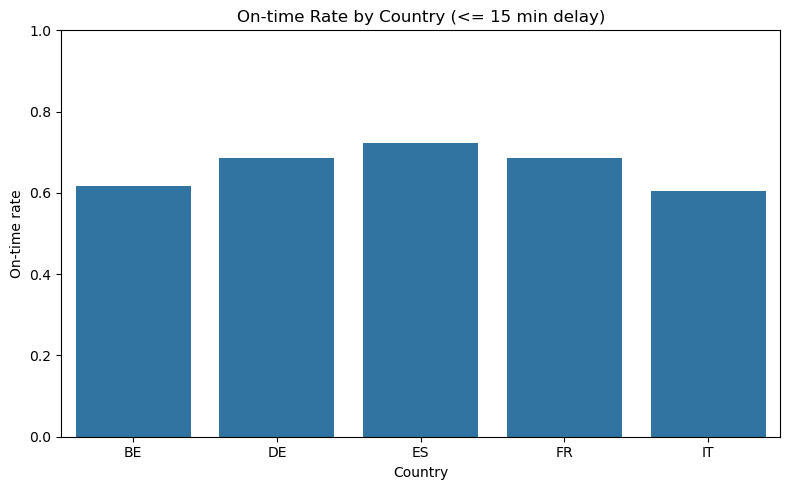

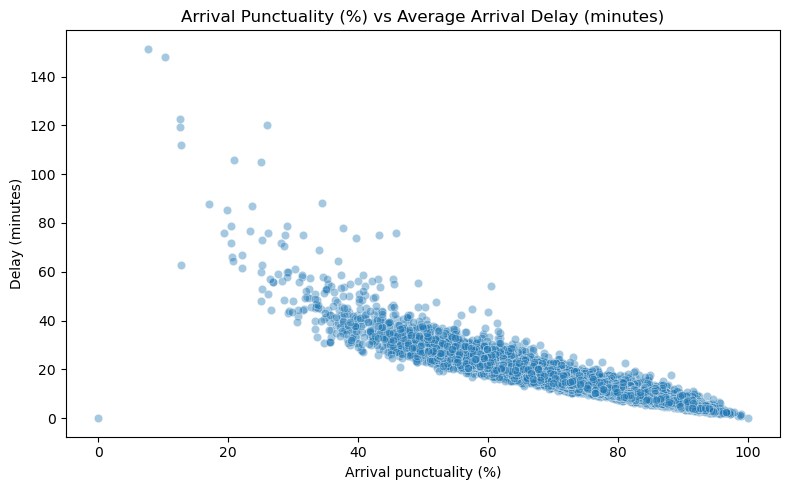

In [21]:
import os
os.makedirs("../figures", exist_ok=True)

# 1) Histogram of delay minutes
plt.figure(figsize=(8,5))
sns.histplot(df_feat["target_delay_minutes"], bins=40, kde=True)
plt.title("Distribution of Average Arrival Schedule Delay (minutes)")
plt.xlabel("Delay (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../figures/hist_delay_minutes.png", dpi=200)
plt.show()

# 2) Boxplot: delay by country
plt.figure(figsize=(8,5))
sns.boxplot(data=df_feat, x="iso_country", y="target_delay_minutes")
plt.title("Average Arrival Delay by Country")
plt.xlabel("Country")
plt.ylabel("Delay (minutes)")
plt.tight_layout()
plt.savefig("../figures/box_delay_by_country.png", dpi=200)
plt.show()

# 3) Line: average delay by month
plt.figure(figsize=(8,5))
monthly = df_feat.groupby("month")["target_delay_minutes"].mean().reset_index()
sns.lineplot(data=monthly, x="month", y="target_delay_minutes", marker="o")
plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Delay (minutes)")
plt.tight_layout()
plt.savefig("../figures/line_delay_by_month.png", dpi=200)
plt.show()

# 4) Bar: on-time (not delayed >15) rate by country
plt.figure(figsize=(8,5))
rate = (1 - df_feat.groupby("iso_country")["target_delayed_15"].mean()).reset_index(name="on_time_rate")
sns.barplot(data=rate, x="iso_country", y="on_time_rate")
plt.title("On-time Rate by Country (<= 15 min delay)")
plt.xlabel("Country")
plt.ylabel("On-time rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("../figures/bar_ontime_rate_by_country.png", dpi=200)
plt.show()

# 5) Scatter: punctuality vs delay
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_feat, x="arr_punctuality_pct", y="target_delay_minutes", alpha=0.4)
plt.title("Arrival Punctuality (%) vs Average Arrival Delay (minutes)")
plt.xlabel("Arrival punctuality (%)")
plt.ylabel("Delay (minutes)")
plt.tight_layout()
plt.savefig("../figures/scatter_punctuality_vs_delay.png", dpi=200)
plt.show()

1) Scatter: Arrival punctuality (%) vs average arrival delay (minutes)
Interpretation: The plot shows a clear negative relationship: airports/days with higher arrival punctuality tend to have lower average arrival delay. The curved pattern suggests improvements in punctuality near the high end (e.g., 90% → 98%) correspond to relatively small remaining delay, while low punctuality is associated with much larger delays and higher variability.  
Limitation: This is correlation only; without weather/traffic controls, we cannot claim punctuality “causes” delay reductions.
2) Bar: On-time rate (≤ 15 min delay) by country
Interpretation: On-time performance differs across countries: Spain (ES) appears highest, while Belgium (BE) and Italy (IT) are lower in this sample. This indicates that country-level factors (airport congestion, scheduling, operations, or regional conditions) may influence punctuality outcomes.  
Limitation: Country averages can hide major airport-to-airport differences and depend on which airports are included in the dataset.
3) Line: Average arrival delay by month
Interpretation: Delays show strong seasonality, rising from late winter into summer and peaking in July, then declining toward autumn. This pattern is consistent with seasonal demand and operational pressure (e.g., summer travel peaks) increasing delay risk.  
Limitation: This is aggregated by month across airports and countries, so it may mix different seasonal patterns per country/airport.
4) Boxplot: Average arrival delay by country
Interpretation: The typical delay (median and IQR) is similar across countries and concentrated around roughly 10–20 minutes, but all countries show many extreme outliers reaching very high delays. This suggests that while “normal days” are comparable, rare disruption events (e.g., severe weather, strikes, airspace restrictions) can produce very large delays.  
Limitation: Outliers may dominate perception; consider reporting both median and mean, and optionally using a log scale or trimming for some analyses.
5) Histogram + KDE: Distribution of average arrival delay
Interpretation: The distribution is heavily right-skewed: most airport-days have small delays (around 5–15 minutes), but there is a long tail of large delays up to ~150 minutes. This indicates that extreme delays are uncommon but meaningful and can strongly affect the mean.  
Limitation: Because the target is an average schedule delay (not individual flights), the distribution may be smoother and may under-represent within-day variability.

In [22]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Choose what you want to freeze:
# - df_feat = cleaned + engineered features + targets (recommended)
final_df = df_feat.copy()

out_path = "../data/processed/phase3_airport_day_clean.csv"
final_df.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Final rows:", final_df.shape[0])
print("Final columns:", final_df.shape[1])

assert final_df.shape[0] >= 1000, "Row requirement not met (need >= 1000)."
assert final_df.shape[1] >= 15, "Feature requirement not met (need >= 15 columns/features)."

Saved: ../data/processed/phase3_airport_day_clean.csv
Final rows: 16069
Final columns: 35
